In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [28]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.plotting_styles import apply_global_style

In [29]:
from src.load_sam_data import load_dataset
from src.autoencoders import drop_empty_histograms
from src.autoencoders import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

..\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [ ]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [36]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(96, 64),  
            nn.ReLU(),

            nn.Linear(64, 32),  
            nn.ReLU(),
            
            nn.Linear(32, 16),  
            nn.Sigmoid(),
            )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 96),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [37]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [38]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_lin = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_lin.parameters(), lr=0.0005)

In [39]:
from src.autoencoders import train_ae

ae_lin.train()
train_losses, val_losses, ae_lin = train_ae(n_epochs=40, dataloader=train_loader, model=ae_lin, val_loader=test_loader, optimizer=optimizer, criterion=criterion)

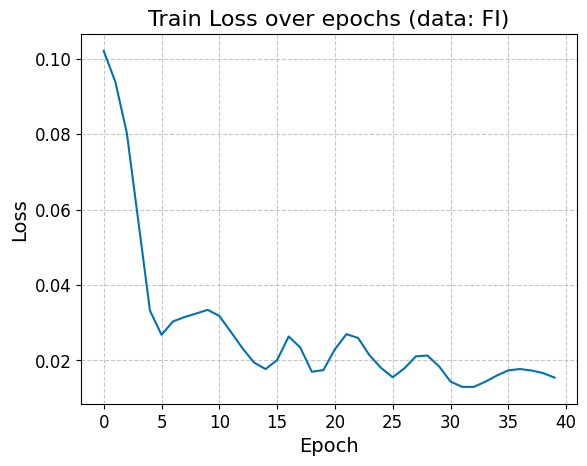

In [40]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

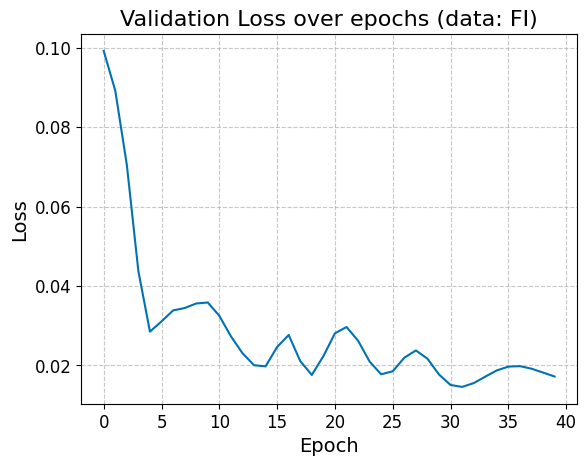

In [41]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([96])) that is different to the input size (torch.Size([1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


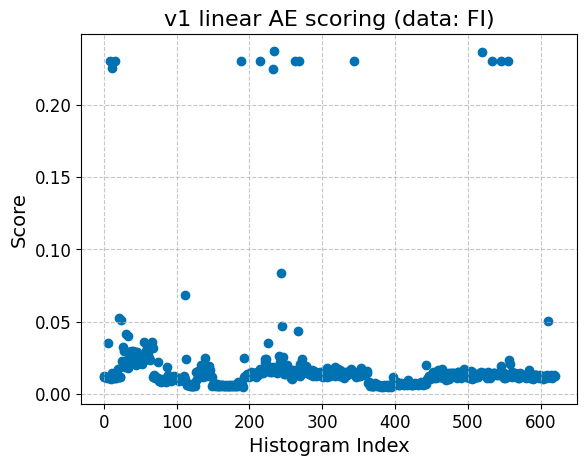

In [42]:
from src.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 linear AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)
score = eval_and_plot_score(model=ae_lin, dataloader=full_dataset, criterion=criterion)

Locating outliers same as kNN and OCSVM but not discovering point 363 (which may or may not be considered)

In [51]:
outliers = np.where(np.array(score) > 0.15)
print(len(outliers[0]))
print(outliers[0].tolist())

14
[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]


In [64]:
for idx, pt in enumerate(outliers[0].tolist()):
    if dataset[pt].any() == np.zeros(96).any():
        print(pt)

8
15
188
214
263
268
533
546


In [44]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_lin(data).numpy()
         
        for p in preds:
            if pred.all() == p.all():
                break
        else:
            preds.append(pred)
len(preds)

1

tensor(0.0194)


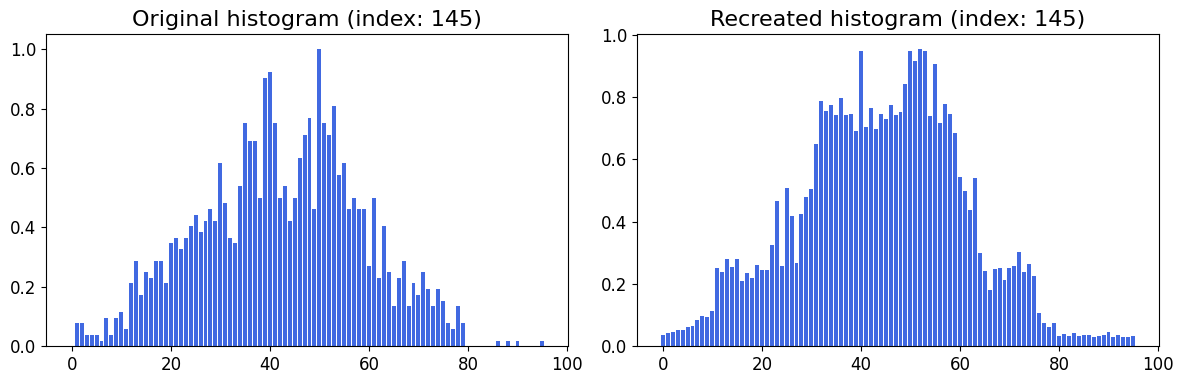

In [65]:
idx = 145

ae_lin.eval()
pred = ae_lin(full_dataset[idx]).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
print(loss)
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)

plt.tight_layout()
plt.show()

In [46]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-10:])

highest scores [234, 520, 8, 15, 188, 214, 263, 268, 533, 546]
lowest scores [120, 158, 371, 382, 391, 381, 390, 191, 384, 394]


## Let's observe latent space

In [71]:
idx = 20
pt = full_dataset[idx]
ae_lin.eval()
embedding = ae_lin.encoder(full_dataset[idx]).detach()
print(embedding.squeeze().numpy())

[1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.]


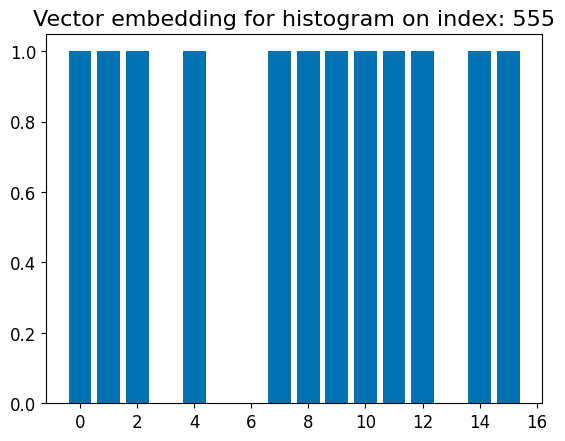

In [82]:
idx = 555
pt = full_dataset[idx]

ae_lin.eval()
with torch.no_grad():
    embedding = ae_lin.encoder(pt).squeeze().cpu().numpy()
plt.title(f"Vector embedding for histogram on index: {idx}")
plt.bar(range(len(embedding)), embedding)
plt.show()